## Домашнее задание 4

Мы продолжаем работу над визуализацией. В этот раз нужно создать визуализации результатов работы алгоритмов обучения с учителем и без учителя, проанализировать изменения параметров и ROC-кривых при изменении гиперпараметров модели, обсудить различия в результатах работы моделей.

Будем работать с тремя датасетами. Перед каждым заданием будет его описание.

Не пугайтесь количеству импортированных библиотек — это шпаргалка со всеми библиотеками, которые мы использовали в четвертом модуле. В этом задании будем использовать несколько из них.

In [1]:
!pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.8/219.8 kB 4.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification, make_moons, make_circles, make_blobs
from scipy.stats import norm
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier
from keras.models import Sequential
from keras.layers import Dense
from sklearn.cluster import DBSCAN, SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances_argmin_min
from pyod.models.hbos import HBOS

Первый датасет — данные по весу и росту в зависимости от пола. В нем нет разметки, поэтому необходимо использовать методы обучения без учителя.

Импортируем датасет и визуально посмотрим на него перед началом работы:

In [3]:
weight_height = pd.read_csv('https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_04_visualization/data/weight-height.csv')
weight_height.head(10)

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
5,Male,67.253016,152.212156
6,Male,68.785081,183.927889
7,Male,68.348516,167.971110
8,Male,67.018950,175.929440
9,Male,63.456494,156.399676


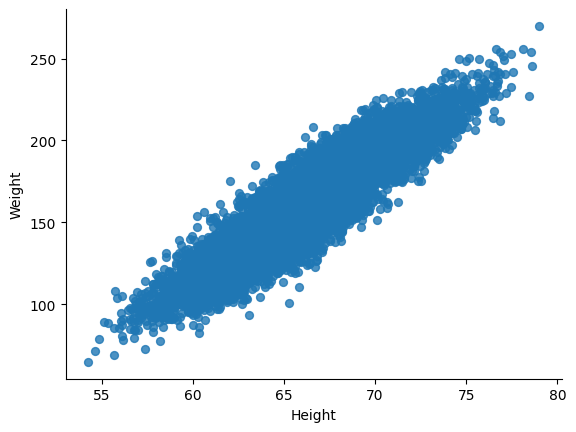

In [4]:
weight_height.plot(kind='scatter', x='Height', y='Weight', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [11]:
weight_height.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


## Задание 1. Сравнение моделей обучения с учителем (6 баллов)

Используя разные алгоритмы машинного обучения, проанализируйте наш датасет на наличие выбросов и аномалий. В качестве переменных для анализа используйте только вес и рост.

Создайте поле из 6 графиков. Каждый график (scatter plot) должен иметь заголовок, названия полей, прозрачность точек 0.8. Должны отсутствовать рамки со всех сторон. Пометьте аномалии красным цветом, а все остальные данные — зеленым.

Поместите на графики следующие 6 алгоритмов:
- Interquartile range (IQR) — возьмите выбросы по `x` и `y`.
- Isolation forest.
- Local Outlier Factor.
- One-class SVM.
- Gaussian Mixture.
- DBSCAN.

Напишите, какие модели показали себя лучше всего и почему.

**Критерии оценивания:**

- 1 балл за каждую правильно построенную модель и корректно выведенные выбросы (всего 3 балла).
- 1 балл за правильное оформление графиков и полотна графиков.

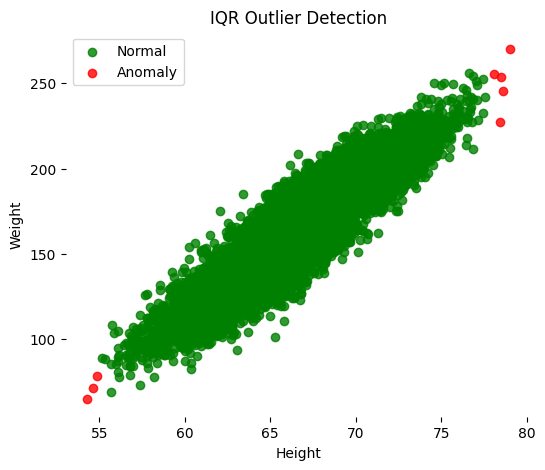

In [17]:
# Interquartile range (IQR) — возьмите выбросы по x и y
q1_w = weight_height.Weight.quantile(0.25)
q3_w = weight_height.Weight.quantile(0.75)
iqr_w = q3_w - q1_w

lower_bound_w = q1_w - 1.5 * iqr_w
upper_bound_w = q3_w + 1.5 * iqr_w

q1_h = weight_height.Height.quantile(0.25)
q3_h = weight_height.Height.quantile(0.75)
iqr_h = q3_h - q1_h

lower_bound_h = q1_h - 1.5 * iqr_h
upper_bound_h = q3_h + 1.5 * iqr_h

outliers = (
    (weight_height['Height'] < lower_bound_h) |
    (weight_height['Height'] > upper_bound_h) |
    (weight_height['Weight'] < lower_bound_w) |
    (weight_height['Weight'] > upper_bound_w)
)

normal = weight_height[~outliers]
anomalies = weight_height[outliers]

plt.figure(figsize=(6,5))

plt.scatter(
    normal['Height'],
    normal['Weight'],
    color='green',
    alpha=0.8,
    label='Normal'
)

plt.scatter(
    anomalies['Height'],
    anomalies['Weight'],
    color='red',
    alpha=0.8,
    label='Anomaly'
)

plt.title('IQR Outlier Detection')
plt.xlabel('Height')
plt.ylabel('Weight')

plt.legend()

plt.gca().spines[['top','right','left','bottom']].set_visible(False)

plt.show()


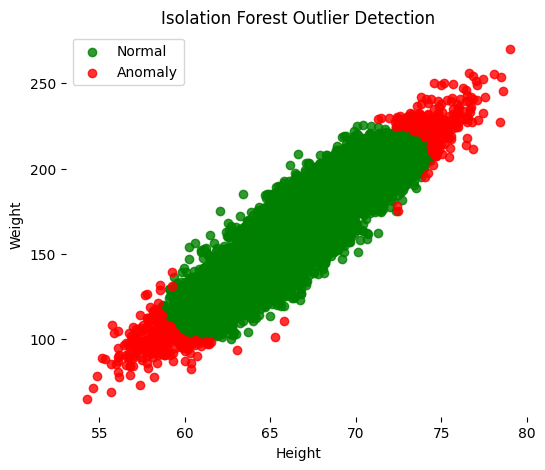

In [18]:
# Isolation forest.

X = weight_height[['Height', 'Weight']]
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
pred = iso_forest.fit_predict(X)

normal = weight_height[pred == 1]
anomalies = weight_height[pred == -1]

plt.figure(figsize=(6, 5))

plt.scatter(
    normal['Height'],
    normal['Weight'],
    color='green',
    alpha=0.8,
    label='Normal'
)

plt.scatter(
    anomalies['Height'],
    anomalies['Weight'],
    color='red',
    alpha=0.8,
    label='Anomaly'
)

plt.title('Isolation Forest Outlier Detection')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()

plt.gca().spines[['top', 'right', 'left', 'bottom']].set_visible(False)

plt.show()

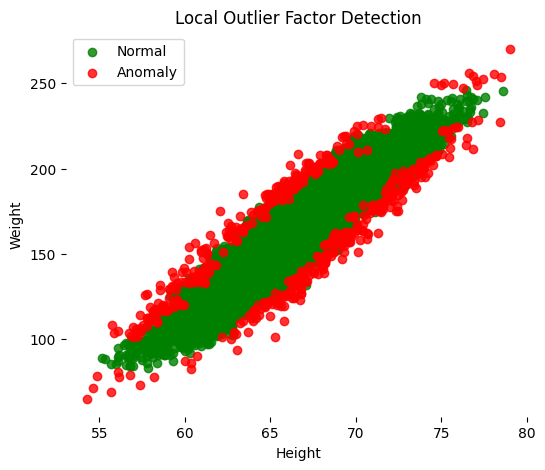

In [19]:
# Local Outlier Factor.

X = weight_height[['Height', 'Weight']]
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
pred = lof.fit_predict(X)

normal = weight_height[pred == 1]
anomalies = weight_height[pred == -1]

plt.figure(figsize=(6,5))

plt.scatter(
    normal['Height'],
    normal['Weight'],
    color='green',
    alpha=0.8,
    label='Normal'
)

plt.scatter(
    anomalies['Height'],
    anomalies['Weight'],
    color='red',
    alpha=0.8,
    label='Anomaly'
)

plt.title('Local Outlier Factor Detection')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()

plt.gca().spines[['top','right','left','bottom']].set_visible(False)

plt.show()

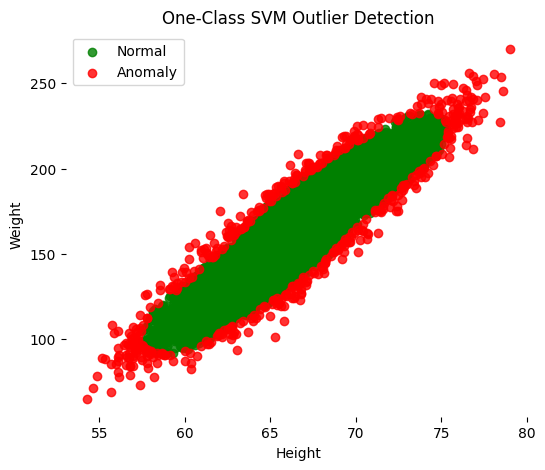

In [20]:
# One-class SVM.

X = weight_height[['Height', 'Weight']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

oc_svm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
pred = oc_svm.fit_predict(X_scaled)

normal = weight_height[pred == 1]
anomalies = weight_height[pred == -1]

plt.figure(figsize=(6,5))

plt.scatter(
    normal['Height'],
    normal['Weight'],
    color='green',
    alpha=0.8,
    label='Normal'
)

plt.scatter(
    anomalies['Height'],
    anomalies['Weight'],
    color='red',
    alpha=0.8,
    label='Anomaly'
)

plt.title('One-Class SVM Outlier Detection')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()

plt.gca().spines[['top', 'right', 'left', 'bottom']].set_visible(False)

plt.show()



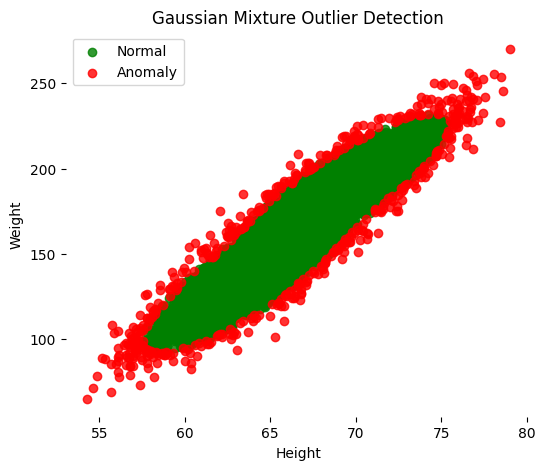

In [21]:
# Gaussian Mixture.

X = weight_height[['Height', 'Weight']]

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X)

scores = gmm.score_samples(X)

threshold = np.percentile(scores, 5)

normal = weight_height[scores >= threshold]
anomalies = weight_height[scores < threshold]

plt.figure(figsize=(6,5))

plt.scatter(
    normal['Height'],
    normal['Weight'],
    color='green',
    alpha=0.8,
    label='Normal'
)

plt.scatter(
    anomalies['Height'],
    anomalies['Weight'],
    color='red',
    alpha=0.8,
    label='Anomaly'
)

plt.title('Gaussian Mixture Outlier Detection')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()

plt.gca().spines[['top','right','left','bottom']].set_visible(False)

plt.show()

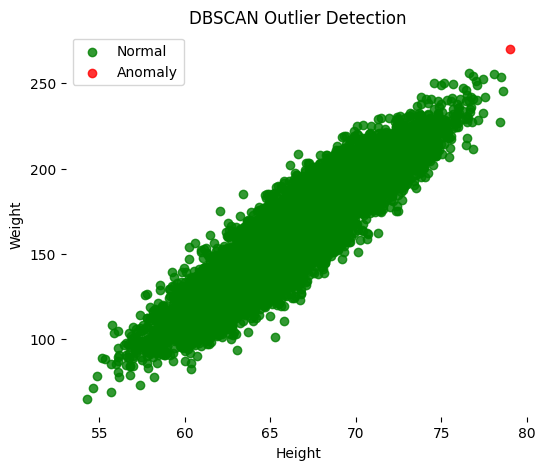

In [22]:
# DBSCAN.

X = weight_height[['Height', 'Weight']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.5, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

normal = weight_height[labels == 0]
anomalies = weight_height[labels == -1]

plt.figure(figsize=(6,5))

plt.scatter(
    normal['Height'],
    normal['Weight'],
    color='green',
    alpha=0.8,
    label='Normal'
)

plt.scatter(
    anomalies['Height'],
    anomalies['Weight'],
    color='red',
    alpha=0.8,
    label='Anomaly'
)

plt.title('DBSCAN Outlier Detection')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend()

plt.gca().spines[['top','right','left','bottom']].set_visible(False)

plt.show()

### **IQR:**
Метод IQR обнаружил только несколько крайних точек, поскольку он ищет выбросы отдельно по каждому признаку и не учитывает взаимосвязь между ростом и весом.


### **Isolation Forest:**
Isolation Forest показал наиболее разумный результат, выделив точки на границах распределения, где плотность данных становится ниже.


### **Local Outlier Factor:**
LOF определил слишком много точек как аномалии, так как метод чувствителен к локальной плотности и в данном наборе данных она меняется постепенно.


### **One-Class SVM:**
One-Class SVM также отметил большое количество точек как выбросы, потому что модель чувствительна к параметрам и может слишком строго ограничивать область нормальных данных.


### **Gaussian Mixture:**
Gaussian Mixture выделил много аномалий, поскольку предполагает нормальное распределение данных, которое не полностью соответствует форме распределения в датасете.


### **DBSCAN:**
DBSCAN практически не обнаружил аномалий, так как данные образуют один плотный кластер и большинство точек имеют достаточное количество соседей.

## Задания 2 и 3

Используя датасет, определите оптимальные параметры модели Isolation Forest с помощью кросс-валидации.

Наш датасет — это набор данных, первоначально взятый [из набора данных UCI](https://dataverse.harvard.edu/file.xhtml?persistentId=doi:10.7910/DVN/OPQMVF/CJURKL&version=1.0) о заболеваниях щитовидной железы. Он содержит 16 категориальных атрибутов, 5 числовых атрибутов и 1 целевой атрибут. Всего — 22 атрибута.

In [6]:
thyroid = pd.read_csv('https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_04_visualization/data/annthyroid_unsupervised_anomaly_detection.csv', sep=';').iloc[:, :-2]
thyroid.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,49.0,3.0,5.0,116.0,4.0,o


## Задание 2. Проверка влияния параметров Isolation Forest на итоговые параметры (4 балла)

После обучения модели выполните следующее:

- Обучите модель Isolation Forest на данных Х с использованием найденных оптимальных параметров (для этого оберните Isolation Forest в [sklearn.model_selection.GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)). В `GridSearchCV` используйте `params = {'n_estimators': list(range(5, 15)), 'max_features': list(range(2, 10))}`.
- Сделайте предсказания на данных Х.
- Поиграйте с параметром `n_jobs` — создайте 6 разных визуализаций с параметрами от 1 до 6.
- Замените значения предсказаний, где 1 соответствует «нормальному» наблюдению (normal), а -1 — «выбросу» (outlier).
- Выведите лучшие параметры модели Isolation Forest для всех 6 параметров (для лучшего понимания оформите выводы).

**Критерии оценивания:**
- 1 балл за правильное использование `GridSearchCV` для подбора параметров в `IsolationForest`.
- 1 балл за правильный вывод параметров для шести моделей с разным параметром `n_jobs`.



In [23]:
thyroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6916 non-null   float64
 1   Sex                        6916 non-null   float64
 2   on_thyroxine               6916 non-null   float64
 3   query_on_thyroxine         6916 non-null   float64
 4   on_antithyroid_medication  6916 non-null   float64
 5   sick                       6916 non-null   float64
 6   pregnant                   6916 non-null   float64
 7   thyroid_surgery            6916 non-null   float64
 8   I131_treatment             6916 non-null   float64
 9   query_hypothyroid          6916 non-null   float64
 10  query_hyperthyroid         6916 non-null   float64
 11  lithium                    6916 non-null   float64
 12  goitre                     6916 non-null   float64
 13  tumor                      6916 non-null   float

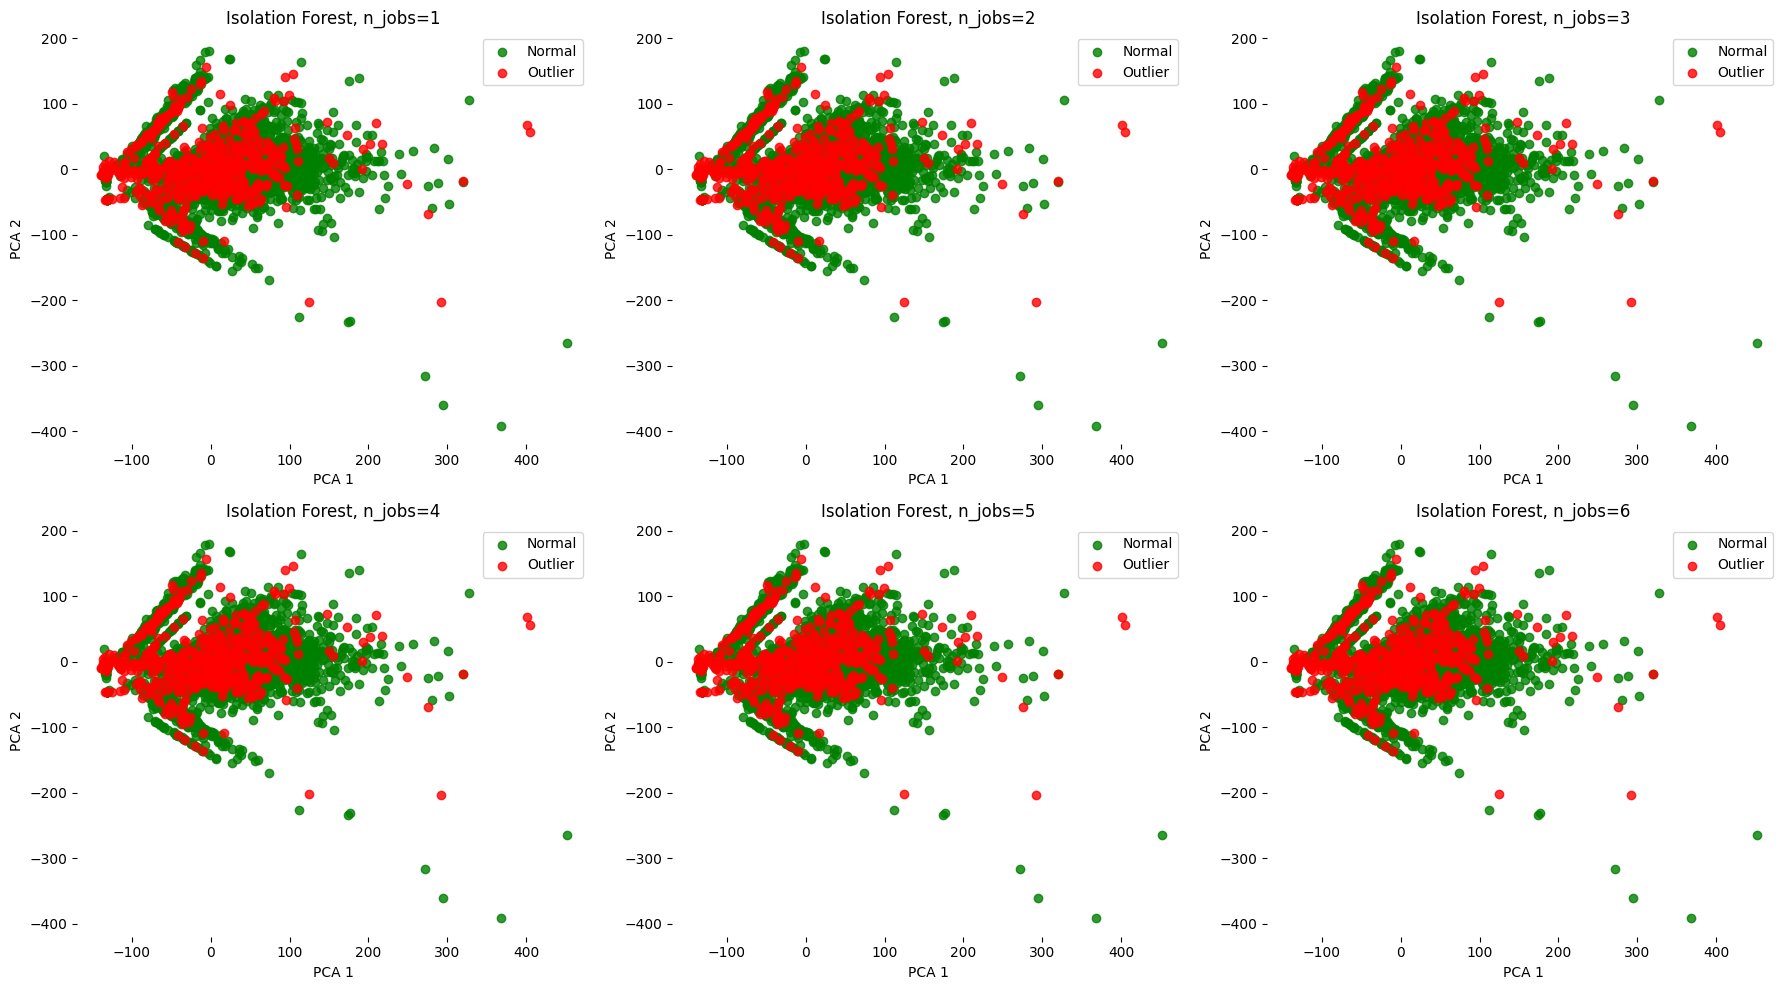

,n_jobs,best_n_estimators,best_max_features,best_score,normal_count,outlier_count
0,1,13,2,0.161889,6374,542
1,2,13,2,0.161889,6374,542
2,3,13,2,0.161889,6374,542
3,4,13,2,0.161889,6374,542
4,5,13,2,0.161889,6374,542
5,6,13,2,0.161889,6374,542


In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, make_scorer
from sklearn.decomposition import PCA

X = thyroid.iloc[:, :-1]
y = thyroid.iloc[:, -1]

y = y.map({'n': 0, 'o': 1})
y = pd.Series(y).astype(int)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

def iforest_f1_score(y_true, y_pred):
    y_pred_converted = np.where(y_pred == 1, 0, 1)
    return f1_score(y_true, y_pred_converted)

scorer = make_scorer(iforest_f1_score)

params = {
    'n_estimators': list(range(5, 15)),
    'max_features': list(range(2, 10))
}

results = []

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, n_jobs_value in enumerate(range(1, 7)):
    model = IsolationForest(
        contamination='auto',
        random_state=42
    )

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring=scorer,
        cv=3,
        n_jobs=n_jobs_value
    )

    grid.fit(X, y)

    best_model = grid.best_estimator_
    preds = best_model.predict(X)

    pred_labels = np.where(preds == 1, 'normal', 'outlier')

    results.append({
        'n_jobs': n_jobs_value,
        'best_n_estimators': grid.best_params_['n_estimators'],
        'best_max_features': grid.best_params_['max_features'],
        'best_score': grid.best_score_,
        'normal_count': np.sum(pred_labels == 'normal'),
        'outlier_count': np.sum(pred_labels == 'outlier')
    })

    ax = axes[i]

    normal_mask = pred_labels == 'normal'
    outlier_mask = pred_labels == 'outlier'

    ax.scatter(
        X_pca[normal_mask, 0],
        X_pca[normal_mask, 1],
        color='green',
        alpha=0.8,
        label='Normal'
    )

    ax.scatter(
        X_pca[outlier_mask, 0],
        X_pca[outlier_mask, 1],
        color='red',
        alpha=0.8,
        label='Outlier'
    )

    ax.set_title(f'Isolation Forest, n_jobs={n_jobs_value}')
    ax.set_xlabel('PCA 1')
    ax.set_ylabel('PCA 2')
    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
    ax.legend()

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
results_df

### **n_jobs от 1 до 6**
При изменении параметра n_jobs от 1 до 6 лучшие гиперпараметры модели IsolationForest не изменились. Это связано с тем, что параметр n_jobs влияет только на параллельность вычислений и скорость работы GridSearchCV, но не влияет на сам алгоритм обучения. Поскольку использовались одинаковые данные, одинаковая сетка гиперпараметров, одинаковая метрика и фиксированный random_state, все шесть запусков дали одинаковый результат.

## Задание 3. Визуализация ROC-кривой в зависимости от параметров Isolation Forest (4 балла)

- Для каждого Isolation Forest создайте отдельную `roc_curve` и полотно с шестью графиками для визуализации шести ROC-кривых в зависимости от параметра n_jobs.
- В название каждого графика выведите F1-score, Precision и Recall для каждой модели Isolation Forest.

**Критерии оценивания:**

- 1 балл за правильно построенные визуализации ROC-кривой.
- 1 балл за вывод правильных F1-score, Precision, Recall.

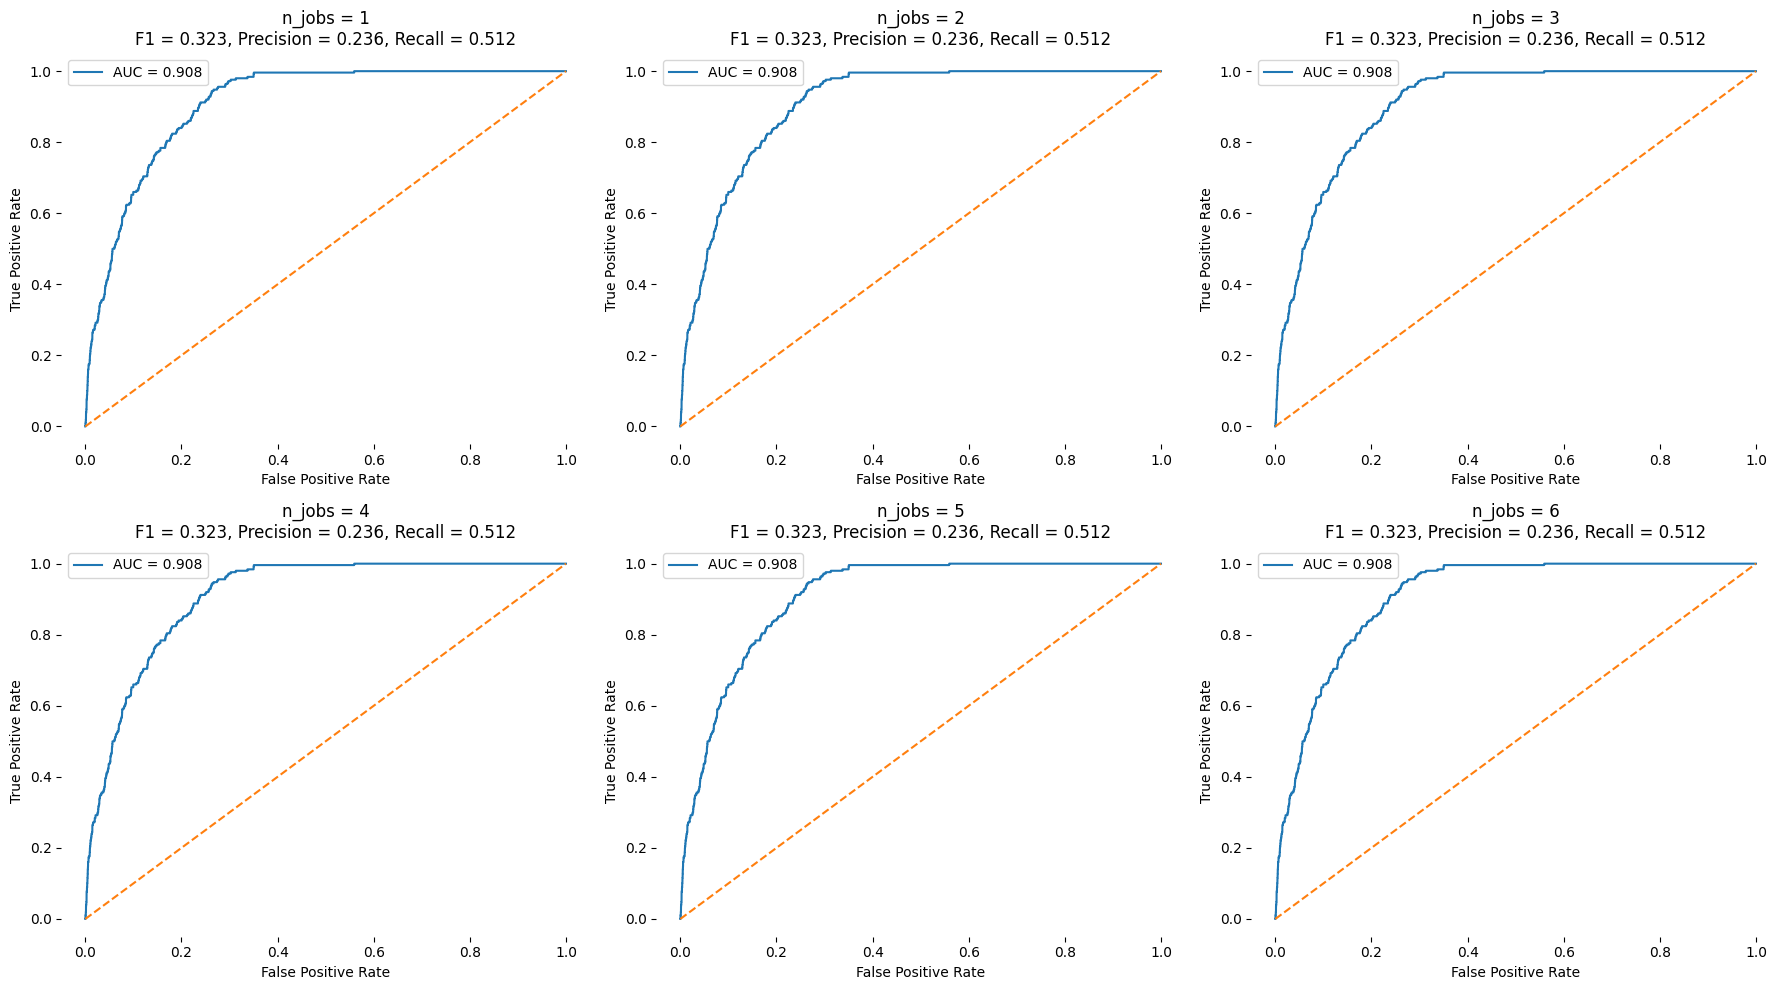

,n_jobs,f1_score,precision,recall,roc_auc
0,1,0.323232,0.236162,0.512,0.907832
1,2,0.323232,0.236162,0.512,0.907832
2,3,0.323232,0.236162,0.512,0.907832
3,4,0.323232,0.236162,0.512,0.907832
4,5,0.323232,0.236162,0.512,0.907832
5,6,0.323232,0.236162,0.512,0.907832


In [38]:
from sklearn.metrics import precision_score, recall_score, roc_curve, auc

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

roc_results = []

for i, row in results_df.iterrows():

    n_jobs_value = int(row['n_jobs'])
    n_estimators = int(row['best_n_estimators'])
    max_features = int(row['best_max_features'])

    model = IsolationForest(
        n_estimators=n_estimators,
        max_features=max_features,
        contamination='auto',
        random_state=42,
        n_jobs=n_jobs_value
    )

    model.fit(X)

    y_pred_raw = model.predict(X)
    y_pred = np.where(y_pred_raw == 1, 0, 1)

    anomaly_score = -model.decision_function(X)

    f1 = f1_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)

    fpr, tpr, thresholds = roc_curve(y, anomaly_score)
    roc_auc = auc(fpr, tpr)

    roc_results.append({
        'n_jobs': n_jobs_value,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'roc_auc': roc_auc
    })

    ax = axes[i]

    ax.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], linestyle='--')

    ax.set_title(
        f'n_jobs = {n_jobs_value}\n'
        f'F1 = {f1:.3f}, Precision = {precision:.3f}, Recall = {recall:.3f}'
    )

    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()

    ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)

plt.tight_layout()
plt.show()

roc_results_df = pd.DataFrame(roc_results)
roc_results_df

### **ROC-кривая модели IsolationForest**
Для каждого значения n_jobs была построена отдельная ROC-кривая модели IsolationForest с оптимальными параметрами, найденными на предыдущем шаге. Все шесть ROC-кривых совпали, так же как и значения F1-score, Precision, Recall и AUC. Это объясняется тем, что параметр n_jobs влияет только на скорость и параллельность вычислений, но не влияет на качество модели при фиксированных данных, гиперпараметрах и random_state.

## Задание 4. Проверка эффективности моделей без учителя (6 баллов)

Ранее мы обсуждали, что методы обучения с учителем можно использовать не только для поиска аномалий, но и для классической классификации. Аналогично первому заданию, используя разные алгоритмы обучения с учителем, постройте модель для классификации по данным датасета.

Наш третий датасет — данные по принятым и не принятым в университет студентам в зависимости от их среднего балла и балла за экзамен.
В качестве переменных для анализа используйте средний балл (**cgpa**) и балл за экзамен (**placement_exam_marks**), а в качестве зависимой переменной в кластеризации используйте переменную **placed**.

Создайте поле из шести графиков. Каждый график должен представлять собой confusion_matrix (heatmap или тепловую карту) с попаданиями модели (матрица 2 на 2 с попаданиями модели, как делали на третьей неделе). Каждый график должен иметь заголовок и названия полей. На тепловой карте на каждом квадратике должно быть указано число, а также colorbar с правой стороны.

Поместите на графики следующие 6 алгоритмов:
- k-Nearest Neighbors (KNN).
- SVM (Support Vector Machine).
- Random Forest.
- AdaBoost.
- Gradient Boosting.
- Decision Tree.

**Критерии оценивания:**

- 1 балл за каждые две правильно построенные модели и корректно выведенные выбросы.
- 1 балл за правильное оформление графиков и полотна графиков.

In [9]:
placement = pd.read_csv('https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_04_visualization/data/placement.csv')
placement.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [41]:
placement.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


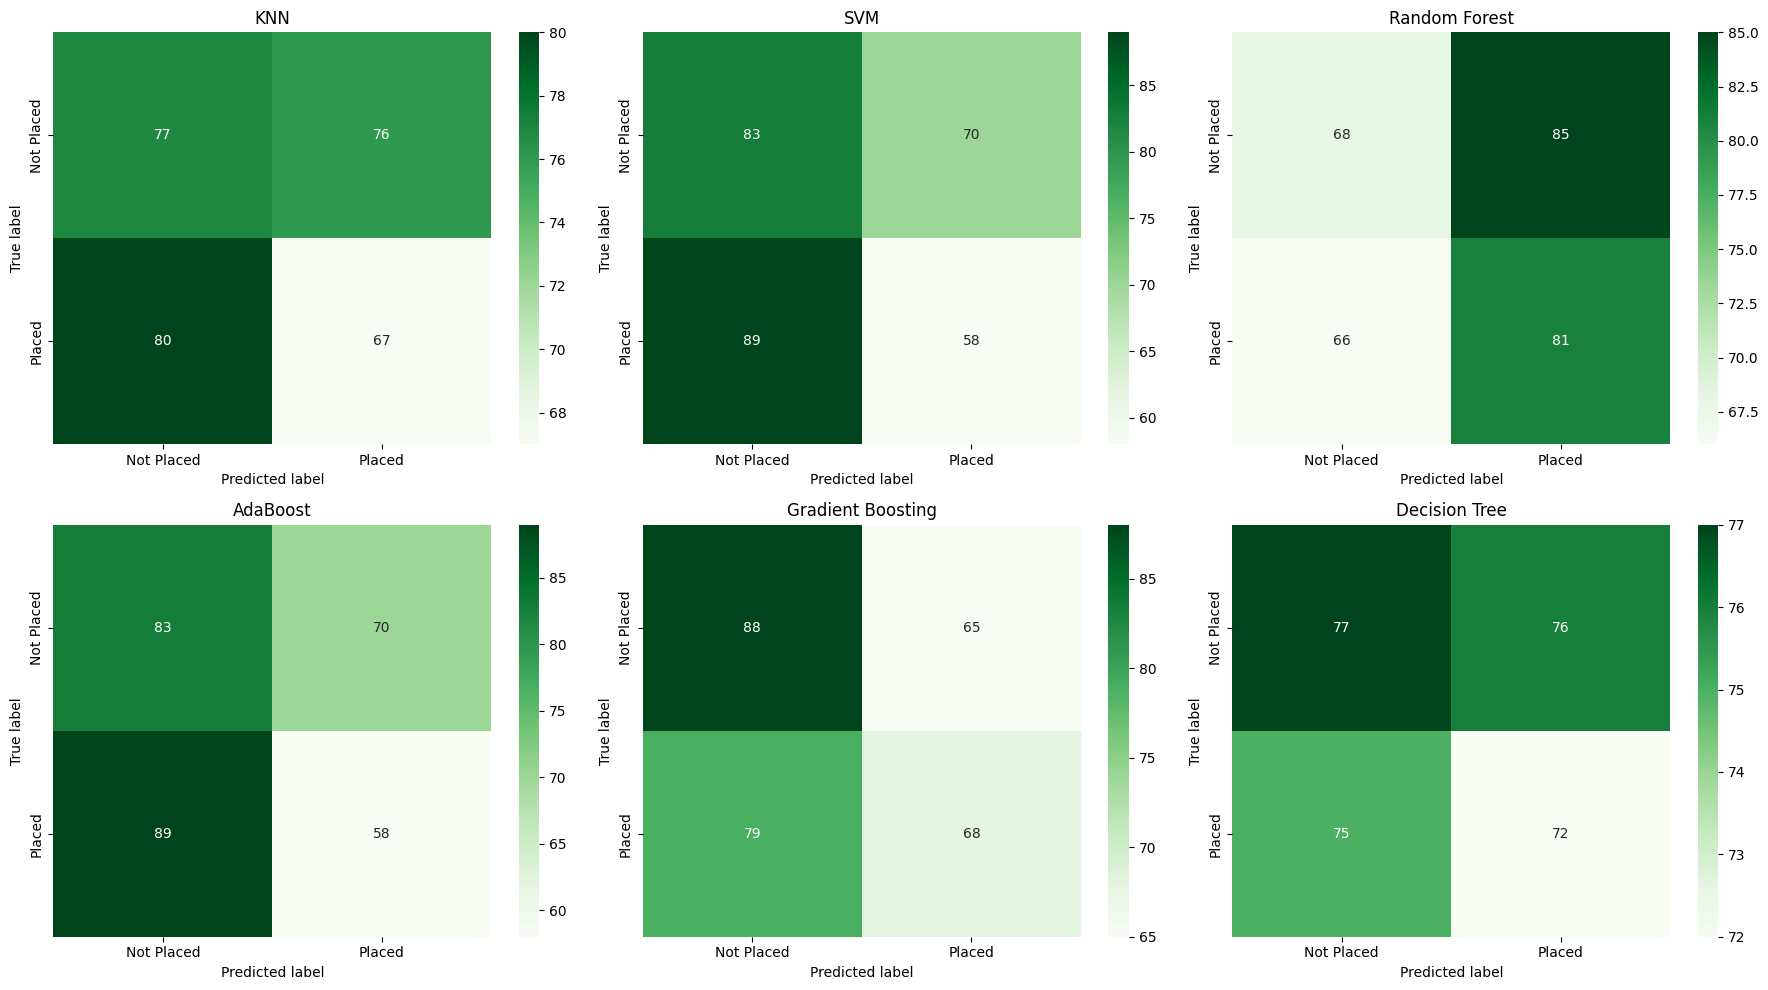

In [43]:
from sklearn.svm import SVC

X = placement[['cgpa', 'placement_exam_marks']]
y = placement['placed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Greens',
        cbar=True,
        ax=ax,
        xticklabels=['Not Placed', 'Placed'],
        yticklabels=['Not Placed', 'Placed']
    )

    ax.set_title(name)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')

plt.tight_layout()
plt.show()


### **6 моделей классификации**

Были обучены шесть моделей классификации: KNN, SVM, Random Forest, AdaBoost, Gradient Boosting и Decision Tree. Для каждой модели была построена матрица ошибок (confusion matrix) в виде тепловой карты. Матрицы позволяют визуально сравнить качество классификации и количество правильных и ошибочных предсказаний для классов Placed и Not Placed. Видно, что различные модели демонстрируют различную точность классификации, что связано с особенностями алгоритмов и структурой данных.

**Итоговый балл за домашнее задание = набранный балл / 2**